# 📓 Complete Jupyter Notebook — Normalization (MinMaxScaler)

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

## Cell 2 — Create Dataset

In [2]:
data = {
    "age": [18, 20, 22, 25, 30, 35, 40],
    "salary": [20000, 25000, 30000, 45000, 60000, 90000, 150000],
    "experience": [0, 1, 2, 3, 5, 8, 12]
}

df = pd.DataFrame(data)

df

,age,salary,experience
0,18,20000,0
1,20,25000,1
2,22,30000,2
3,25,45000,3
4,30,60000,5
5,35,90000,8
6,40,150000,12


## Cell 3 — Check Dataset

In [3]:
print("----- First 5 Rows -----")
print(df.head())

print("\n----- Shape -----")
print(df.shape)

print("\n----- Data Types -----")
print(df.dtypes)

print("\n----- Statistical Summary -----")
print(df.describe())

----- First 5 Rows -----
   age  salary  experience
0   18   20000           0
1   20   25000           1
2   22   30000           2
3   25   45000           3
4   30   60000           5

----- Shape -----
(7, 3)

----- Data Types -----
age           int64
salary        int64
experience    int64
dtype: object

----- Statistical Summary -----
             age         salary  experience
count   7.000000       7.000000    7.000000
mean   27.142857   60000.000000    4.428571
std     8.173709   46457.866216    4.276180
min    18.000000   20000.000000    0.000000
25%    21.000000   27500.000000    1.500000
50%    25.000000   45000.000000    3.000000
75%    32.500000   75000.000000    6.500000
max    40.000000  150000.000000   12.000000


## Cell 4 — Check Minimum and Maximum

In [4]:
print("Minimum Values:")
print(df.min())

print("\nMaximum Values:")
print(df.max())

Minimum Values:
age              18
salary        20000
experience        0
dtype: int64

Maximum Values:
age               40
salary        150000
experience        12
dtype: int64


Yahan aapko har feature ka Minimum aur Maximum pata chalega.

## Cell 5 — Visualize Before Normalization

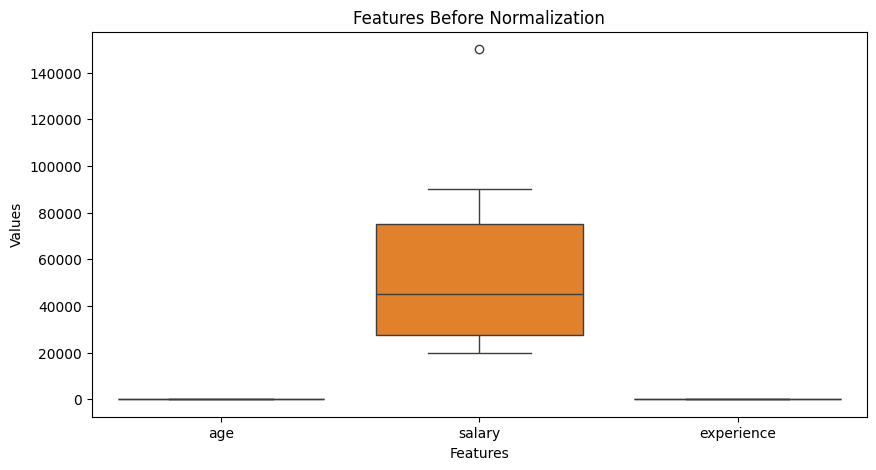

In [5]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df)

plt.title("Features Before Normalization")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

Salary ka scale age aur experience se bahut bada hai.

## Cell 6 — Create MinMaxScaler

In [6]:
scaler = MinMaxScaler()

print(scaler)

MinMaxScaler()


## Cell 7 — Apply Normalization

In [7]:
df_normalized = scaler.fit_transform(df)

df_normalized

array([[0.        , 0.        , 0.        ],
       [0.09090909, 0.03846154, 0.08333333],
       [0.18181818, 0.07692308, 0.16666667],
       [0.31818182, 0.19230769, 0.25      ],
       [0.54545455, 0.30769231, 0.41666667],
       [0.77272727, 0.53846154, 0.66666667],
       [1.        , 1.        , 1.        ]])

`fit_transform()`:

- **fit** → Minimum aur Maximum learn karta hai
- **transform** → Min-Max formula apply karta hai

## Cell 8 — Convert into DataFrame

In [8]:
df_normalized = pd.DataFrame(
    df_normalized,
    columns=df.columns
)

df_normalized

,age,salary,experience
0,0.000000,0.000000,0.000000
1,0.090909,0.038462,0.083333
2,0.181818,0.076923,0.166667
3,0.318182,0.192308,0.250000
4,0.545455,0.307692,0.416667
5,0.772727,0.538462,0.666667
6,1.000000,1.000000,1.000000


Ab values generally `0 ≤ value ≤ 1` hongi.

## Cell 9 — Check Minimum

In [9]:
print("Minimum Values After Normalization:")

print(df_normalized.min())

Minimum Values After Normalization:
age           0.0
salary        0.0
experience    0.0
dtype: float64


Expected: age 0, salary 0, experience 0

## Cell 10 — Check Maximum

In [10]:
print("Maximum Values After Normalization:")

print(df_normalized.max())

Maximum Values After Normalization:
age           1.0
salary        1.0
experience    1.0
dtype: float64


Expected: age 1, salary 1, experience 1

## Cell 11 — Compare Original vs Normalized

In [11]:
comparison = pd.DataFrame({
    "Original Age": df["age"],
    "Normalized Age": df_normalized["age"],

    "Original Salary": df["salary"],
    "Normalized Salary": df_normalized["salary"],

    "Original Experience": df["experience"],
    "Normalized Experience": df_normalized["experience"]
})

comparison

,Original Age,Normalized Age,Original Salary,Normalized Salary,Original Experience,Normalized Experience
0,18,0.000000,20000,0.000000,0,0.000000
1,20,0.090909,25000,0.038462,1,0.083333
2,22,0.181818,30000,0.076923,2,0.166667
3,25,0.318182,45000,0.192308,3,0.250000
4,30,0.545455,60000,0.307692,5,0.416667
5,35,0.772727,90000,0.538462,8,0.666667
6,40,1.000000,150000,1.000000,12,1.000000


Isse easily compare kar sakte ho.

## Cell 12 — Manually Calculate Normalization

Age ka example manually karte hain.

In [12]:
age_min = df["age"].min()
age_max = df["age"].max()

df["age_manual"] = (df["age"] - age_min) / (age_max - age_min)

manual_comparison = pd.DataFrame({
    "Original Age": df["age"],
    "Manual Normalization": df["age_manual"],
    "Sklearn Normalization": df_normalized["age"]
})

manual_comparison

,Original Age,Manual Normalization,Sklearn Normalization
0,18,0.000000,0.000000
1,20,0.090909,0.090909
2,22,0.181818,0.181818
3,25,0.318182,0.318182
4,30,0.545455,0.545455
5,35,0.772727,0.772727
6,40,1.000000,1.000000


In [13]:
print("Manual aur sklearn same hain?", np.allclose(df["age_manual"], df_normalized["age"]))

Manual aur sklearn same hain? True


## Cell 13 — Visualization After Normalization

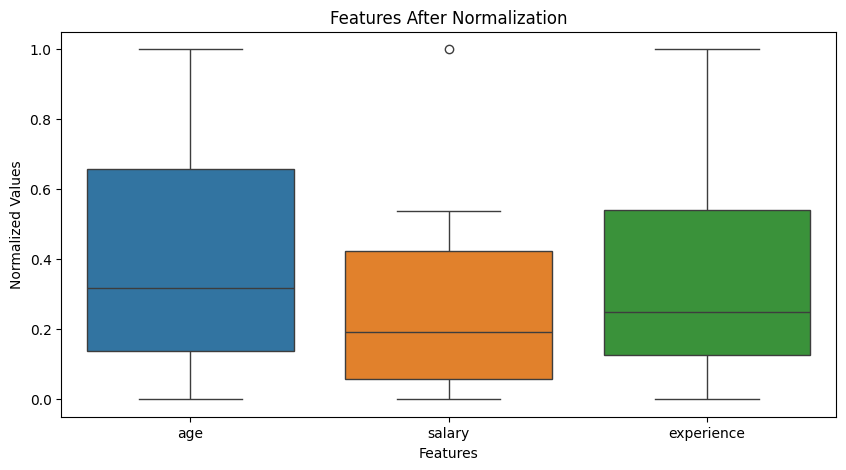

In [14]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_normalized)

plt.title("Features After Normalization")
plt.xlabel("Features")
plt.ylabel("Normalized Values")

plt.show()

Ab teeno features same approximate range mein hain.

## 🎮 Bonus — Min-Max Normalization Game

Sliders se `x`, `x_min`, `x_max` badlo aur dekho `x′` 0–1 bar par kahan aata hai. Neeche challenge mein target value hit karo. Ye `ipywidgets` ke bina bhi chalta hai (HTML + JavaScript iframe).

Tip: `x` ko `x_min` se neeche ya `x_max` se upar le jao. Yehi wajah hai ki test data par `x′` kabhi-kabhi 0–1 se bahar aa jata hai.

In [15]:
from IPython.display import HTML, display
import html as _html

game_html = r"""<!DOCTYPE html><html><head><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1">
<style>
:root{--bg:#f6f7f9;--card:#fff;--fg:#1a1d21;--mut:#6b7280;--acc:#3b82f6;--ok:#16a34a;--bad:#dc2626;--line:#d9dde3}
@media (prefers-color-scheme:dark){:root{--bg:#111214;--card:#1f2023;--fg:#f1f2f4;--mut:#9aa0a8;--line:#35373c}}
body{margin:0;padding:12px;background:var(--bg);color:var(--fg);font-family:system-ui,sans-serif}
.c{max-width:720px;margin:auto;background:var(--card);border:1px solid var(--line);border-radius:14px;padding:16px}
h1{font-size:1.05rem;margin:0 0 8px}.f{text-align:center;font-family:Georgia,serif;font-size:1.1rem;margin:8px 0}
.row{display:flex;align-items:center;gap:10px;margin:8px 0}.row label{width:34px;font-family:Georgia,serif;font-style:italic}
.row output{width:40px;text-align:right}input[type=range]{flex:1;accent-color:var(--acc)}
.bar{position:relative;height:34px;margin:22px 6px 26px;border-radius:8px;background:linear-gradient(90deg,rgba(59,130,246,.15),rgba(59,130,246,.45))}
.tick{position:absolute;top:36px;font-size:.8rem;color:var(--mut);transform:translateX(-50%)}
.m{position:absolute;top:-8px;width:4px;height:50px;background:#ef4444;border-radius:2px;transform:translateX(-50%)}
.g{margin-top:12px;padding-top:12px;border-top:1px solid var(--line)}.msg{min-height:1.4em;color:var(--mut);margin:6px 0}
.ok{color:var(--ok)}.bad{color:var(--bad)}button{background:var(--acc);color:#fff;border:0;border-radius:10px;padding:9px 14px;cursor:pointer}
</style></head><body><div class="c">
<h1>🎮 Min-Max Normalization Game</h1>
<div class="f">x′ = (x − x<sub>min</sub>) / (x<sub>max</sub> − x<sub>min</sub>)</div>
<div class="f" id="calc"></div>
<div class="bar"><div class="m" id="m"></div><span class="tick" style="left:0">0</span><span class="tick" style="left:100%">1</span></div>
<div class="row"><label>x</label><input id="x" type="range" min="0" max="100" step="1" value="30"><output id="xo"></output></div>
<div class="row"><label>x<sub>min</sub></label><input id="mn" type="range" min="0" max="40" step="1" value="10"><output id="mno"></output></div>
<div class="row"><label>x<sub>max</sub></label><input id="mx" type="range" min="50" max="100" step="1" value="90"><output id="mxo"></output></div>
<div class="g"><b id="t"></b><div class="msg" id="msg"></div><button id="n">New challenge</button> <span id="s" style="color:var(--mut)"></span></div>
</div><script>
const $=i=>document.getElementById(i);let target,score=0,done=false;
function draw(){const x=+$("x").value,mn=+$("mn").value,mx=+$("mx").value,v=(x-mn)/(mx-mn);
$("xo").textContent=x;$("mno").textContent=mn;$("mxo").textContent=mx;
$("calc").innerHTML="x′ = ("+x+" − "+mn+") / ("+mx+" − "+mn+") = <b>"+v.toFixed(3)+"</b>"+(v<0||v>1?"<br><small>⚠️ x min–max ke bahar hai, isliye x′ 0–1 se bahar gaya</small>":"");
$("m").style.left=Math.max(-3,Math.min(103,v*100))+"%";
const m=$("msg");if(Math.abs(v-target)<=0.03){m.textContent="✅ HIT! x′ = "+v.toFixed(3);m.className="msg ok";if(!done){done=true;score++}}
else{m.textContent=(v<target?"⬆ Too low":"⬇ Too high")+" — x′ = "+v.toFixed(3);m.className="msg bad"}
$("s").textContent="Score: "+score}
function nc(){target=[0,0.1,0.25,0.5,0.75,0.9,1][Math.floor(Math.random()*7)];done=false;$("t").textContent="🎯 Target: x′ ≈ "+target+" (±0.03)";draw()}
["x","mn","mx"].forEach(i=>$(i).addEventListener("input",draw));$("n").addEventListener("click",nc);nc();
</script></body></html>
"""

display(HTML(
    '<iframe srcdoc="' + _html.escape(game_html, quote=True) + '" '
    'width="100%" height="560" style="border:0;border-radius:12px;"></iframe>'
))

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Cell 14 — Train-Test Split

Real ML project mein pehle train-test split karna important hai.

In [16]:
from sklearn.model_selection import train_test_split

X = df[["age", "salary", "experience"]]

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print("Training Data:")
print(X_train)

print("\nTesting Data:")
print(X_test)

Training Data:
   age  salary  experience
5   35   90000           8
2   22   30000           2
4   30   60000           5
3   25   45000           3
6   40  150000          12

Testing Data:
   age  salary  experience
0   18   20000           0
1   20   25000           1


## Cell 15 — Correct Normalization

In [17]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**Important:**

- Training data: `scaler.fit_transform(X_train)`
- Test data: `scaler.transform(X_test)`

❌ Test data par dobara `fit()` nahi karna.

## Cell 16 — Convert to DataFrame

In [18]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Normalized Training Data:")
print(X_train_scaled)

print("\nNormalized Testing Data:")
print(X_test_scaled)

Normalized Training Data:
        age  salary  experience
5  0.722222   0.500         0.6
2  0.000000   0.000         0.0
4  0.444444   0.250         0.3
3  0.166667   0.125         0.1
6  1.000000   1.000         1.0

Normalized Testing Data:
        age    salary  experience
0 -0.222222 -0.083333        -0.2
1 -0.111111 -0.041667        -0.1


## Cell 17 — Save Normalized Dataset

In [19]:
df_normalized.to_csv(
    "normalized_data.csv",
    index=False
)

print("Normalized dataset saved successfully!")

Normalized dataset saved successfully!


## 🧠 Final Revision

**Definition**

Normalization is a feature scaling technique that transforms numerical values into a fixed range, commonly 0 to 1.

**Formula**

$$ X' = \frac{X-X_{min}}{X_{max}-X_{min}} $$

**Workflow**

```
Original Data
      ↓
Find Minimum
      ↓
Find Maximum
      ↓
Apply Min-Max Formula
      ↓
Normalized Data
      ↓
Range ≈ 0 to 1
```

**Python**

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

## 🧠 One-line memory

**Normalization = numerical values ko generally 0–1 range mein lana.**